# Chest X-Ray Classification

This notebook trains two models for 4-class chest X-ray classification using the COVID-19 Radiography Database:

- COVID
- Lung_Opacity
- Normal
- Viral Pneumonia


## 1. Install and Import Libraries


In [1]:
!pip -q install kagglehub scikit-learn seaborn tqdm

import copy
import hashlib
import os
import random
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import label_binarize
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid")


## 2. Reproducibility and Basic Settings

We set random seeds for Python, NumPy, and PyTorch. The notebook automatically uses GPU if one is available.


In [2]:
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

CLASS_NAMES = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]
CLASS_TO_ID = {name: i for i, name in enumerate(CLASS_NAMES)}
ID_TO_CLASS = {i: name for name, i in CLASS_TO_ID.items()}

IMAGE_SIZE = 224
BATCH_SIZE = 64
NUM_EPOCHS = 5
PATIENCE = 2
N_FOLDS = 5

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)


Using device: cuda


## 3. Download Dataset from Kaggle

For reproducibility, the dataset is downloaded directly from Kaggle with KaggleHub:

```text
tawsifurrahman/covid19-radiography-database
```

After download, KaggleHub gives us a local folder path. The helper function below finds the class folders inside that downloaded dataset.


In [3]:
kaggle_dataset = "tawsifurrahman/covid19-radiography-database"
downloaded = Path(kagglehub.dataset_download(kaggle_dataset))

print("Downloaded Kaggle dataset:", kaggle_dataset)
print("Downloaded path:", downloaded)

def find_dataset_root(path):
    path = Path(path)
    for candidate in [path] + list(path.rglob("COVID")):
        root = candidate if candidate.name != "COVID" else candidate.parent
        if all((root / name / "images").exists() for name in CLASS_NAMES):
            return root
    raise FileNotFoundError("Could not find the class image folders inside the Kaggle download.")

dataset_root = find_dataset_root(downloaded)
print("Dataset root used by notebook:", dataset_root)


Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
Downloaded Kaggle dataset: tawsifurrahman/covid19-radiography-database
Downloaded path: /kaggle/input/covid19-radiography-database
Dataset root used by notebook: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset


## 4. Create DataFrame and Remove Exact Duplicates

The dataframe contains the image path, text label, and encoded label. Exact duplicate images are removed with SHA-256 file hashes before the train-test split to reduce leakage risk.


In [4]:
def file_hash(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()

rows = []
for label in CLASS_NAMES:
    image_dir = dataset_root / label / "images"
    for path in sorted(image_dir.glob("*")):
        if path.suffix.lower() in [".png", ".jpg", ".jpeg"]:
            rows.append({
                "filepath": str(path),
                "label": label,
                "label_encoded": CLASS_TO_ID[label],
                "file_hash": file_hash(path),
            })

df = pd.DataFrame(rows)
print("Images before duplicate removal:", len(df))

df = df.drop_duplicates(subset="file_hash", keep="first").reset_index(drop=True)
print("Images after duplicate removal:", len(df))

df[["filepath", "label", "label_encoded"]].to_csv("cleaned_dataframe.csv", index=False)
display(df.head())
display(df["label"].value_counts())


Images before duplicate removal: 21165
Images after duplicate removal: 21111


,filepath,label,label_encoded,file_hash
0,/kaggle/input/covid19-radiography-database/COV...,COVID,0,cee641860c5fbc230bf8f7d19b2acf2f4de013dbacca44...
1,/kaggle/input/covid19-radiography-database/COV...,COVID,0,cb90c13f9d12709c5470652e7077472c4ffdb273b2b0a5...
2,/kaggle/input/covid19-radiography-database/COV...,COVID,0,f9852c02363c1953a2cab875ac6770ebe55ac9befd8b1d...
3,/kaggle/input/covid19-radiography-database/COV...,COVID,0,6c429f8661936f9aebb7ad1db1c9a6776c215181ceef0e...
4,/kaggle/input/covid19-radiography-database/COV...,COVID,0,24fc6b3846a4b00f8aa5cc194d271b4a74a38a32f969e5...


,count
label,
Normal,10191
Lung_Opacity,6012
COVID,3570
Viral Pneumonia,1338


## 5. Class Distribution Figure

This plot is saved in the `figures/` folder.


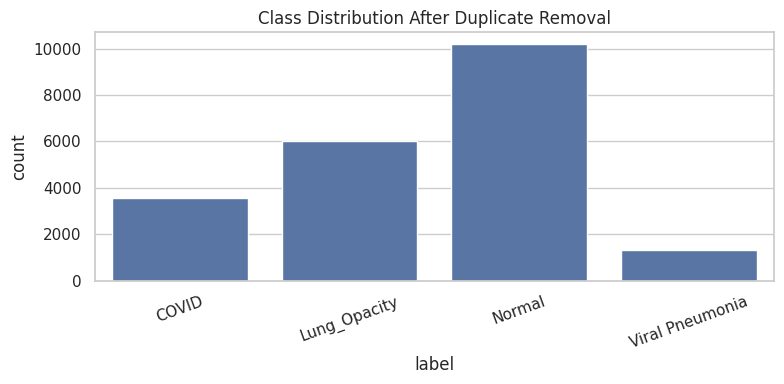

In [5]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="label", order=CLASS_NAMES)
plt.xticks(rotation=20)
plt.title("Class Distribution After Duplicate Removal")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_distribution.png", dpi=300)
plt.show()


## 6. Stratified 80/20 Train-Test Split

The test set is created once and kept untouched until final evaluation. All cross-validation and tuning happen only on `train_df`.


In [6]:
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label_encoded"],
    random_state=SEED,
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_df.to_csv("train_split.csv", index=False)
test_df.to_csv("test_split_untouched.csv", index=False)

print("Training/development images:", len(train_df))
print("Untouched test images:", len(test_df))
print("Hash overlap between train and test:", len(set(train_df.file_hash) & set(test_df.file_hash)))


Training/development images: 16888
Untouched test images: 4223
Hash overlap between train and test: 0


## 7. PyTorch Dataset and DataLoaders

Images are resized to 224x224. Every image is converted to RGB, so grayscale X-rays become 3-channel images. MobileNet models use ImageNet normalization.


In [7]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(7),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

class XrayDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row.filepath).convert("RGB")
        image = self.transform(image)
        label = int(row.label_encoded)
        return image, label

def make_loader(dataframe, transform, shuffle=False, batch_size=BATCH_SIZE):
    dataset = XrayDataset(dataframe, transform)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=2, pin_memory=True)


## 8. Define the Two Models

The CNN is a small baseline trained from scratch. MobileNetV2 uses ImageNet pretrained weights, with the final classifier changed to 4 classes.


In [8]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

def build_model(model_name):
    if model_name == "CNN":
        return SimpleCNN(num_classes=4)

    if model_name == "MobileNetV2":
        weights = models.MobileNet_V2_Weights.DEFAULT
        model = models.mobilenet_v2(weights=weights)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 4)
        return model

    raise ValueError("Unknown model name")

for name in ["CNN", "MobileNetV2"]:
    model = build_model(name)
    total_params = sum(p.numel() for p in model.parameters())
    print(name, "parameters:", f"{total_params:,}")


CNN parameters: 93,764
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 128MB/s]

MobileNetV2 parameters: 2,228,996


## 9. Training and Evaluation Functions

Early stopping saves the best model weights based on validation loss.


In [9]:
def train_one_epoch(model, loader, loss_fn, optimizer):
    model.train()
    total_loss = 0
    correct = 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()

    return total_loss / len(loader.dataset), correct / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss = 0
    correct = 0
    all_labels = []
    all_probs = []

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        probs = F.softmax(outputs, dim=1)

        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    return total_loss / len(loader.dataset), correct / len(loader.dataset), np.array(all_labels), np.array(all_probs)

def train_with_early_stopping(model, train_loader, val_loader, lr, weight_decay, max_epochs=NUM_EPOCHS):
    model = model.to(DEVICE)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    wait = 0
    history = []

    for epoch in range(max_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, loss_fn)

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        })

        print(f"Epoch {epoch+1}: train_acc={train_acc:.4f}, val_acc={val_acc:.4f}, val_loss={val_loss:.4f}")

        if val_loss < best_loss:
            best_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= PATIENCE:
                print("Early stopping")
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


## 10. Simple Hyperparameter Tuning with 5-Fold Cross-Validation

The CNN baseline uses one fixed setting. MobileNetV2 is tested with two learning rates. This keeps the experiment practical while still showing simple transfer-learning tuning. This uses `train_df` only, never the test set.


In [10]:
cnn_params = {"lr": 1e-3, "weight_decay": 1e-4}

mobilenet_param_grid = [
    {"lr": 1e-3, "weight_decay": 1e-4},
    {"lr": 3e-4, "weight_decay": 1e-4},
]

def cross_validate_model(model_name, params):
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    fold_accuracies = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(train_df.filepath, train_df.label_encoded), start=1):
        print(f"\n{model_name} | lr={params['lr']} wd={params['weight_decay']} | Fold {fold}")

        fold_train_df = train_df.iloc[train_idx].reset_index(drop=True)
        fold_val_df = train_df.iloc[val_idx].reset_index(drop=True)

        train_loader = make_loader(fold_train_df, train_transform, shuffle=True)
        val_loader = make_loader(fold_val_df, test_transform, shuffle=False)

        model = build_model(model_name)
        model, history = train_with_early_stopping(
            model,
            train_loader,
            val_loader,
            lr=params["lr"],
            weight_decay=params["weight_decay"],
        )

        val_loss, val_acc, _, _ = evaluate(model, val_loader, nn.CrossEntropyLoss())
        fold_accuracies.append(val_acc)
        print(f"Fold {fold} accuracy: {val_acc:.4f}")

    return fold_accuracies

cv_results = []

# One fixed CNN baseline run.
cnn_fold_accs = cross_validate_model("CNN", cnn_params)
cv_results.append({
    "model": "CNN",
    "lr": cnn_params["lr"],
    "weight_decay": cnn_params["weight_decay"],
    "fold_accuracies": cnn_fold_accs,
    "mean_accuracy": np.mean(cnn_fold_accs),
    "std_accuracy": np.std(cnn_fold_accs),
})

# Tune only MobileNetV2 with two learning rates.
for params in mobilenet_param_grid:
    fold_accs = cross_validate_model("MobileNetV2", params)
    cv_results.append({
        "model": "MobileNetV2",
        "lr": params["lr"],
        "weight_decay": params["weight_decay"],
        "fold_accuracies": fold_accs,
        "mean_accuracy": np.mean(fold_accs),
        "std_accuracy": np.std(fold_accs),
    })

cv_results_df = pd.DataFrame(cv_results)
display(cv_results_df[["model", "lr", "weight_decay", "mean_accuracy", "std_accuracy"]])
cv_results_df.to_csv("cross_validation_results.csv", index=False)



CNN | lr=0.001 wd=0.0001 | Fold 1
Epoch 1: train_acc=0.4825, val_acc=0.4828, val_loss=1.1333
Epoch 2: train_acc=0.5378, val_acc=0.6119, val_loss=1.0073
Epoch 3: train_acc=0.5876, val_acc=0.5986, val_loss=0.9365
Epoch 4: train_acc=0.6187, val_acc=0.6649, val_loss=0.8580
Epoch 5: train_acc=0.6444, val_acc=0.6560, val_loss=0.8612
Fold 1 accuracy: 0.6649

CNN | lr=0.001 wd=0.0001 | Fold 2
Epoch 1: train_acc=0.4794, val_acc=0.5222, val_loss=1.1266
Epoch 2: train_acc=0.5503, val_acc=0.5663, val_loss=1.0890
Epoch 3: train_acc=0.5839, val_acc=0.5870, val_loss=1.0187
Epoch 4: train_acc=0.6220, val_acc=0.6528, val_loss=0.8858
Epoch 5: train_acc=0.6466, val_acc=0.6400, val_loss=0.8484
Fold 2 accuracy: 0.6400

CNN | lr=0.001 wd=0.0001 | Fold 3
Epoch 1: train_acc=0.4843, val_acc=0.5098, val_loss=1.0954
Epoch 2: train_acc=0.5715, val_acc=0.6083, val_loss=1.0030
Epoch 3: train_acc=0.5984, val_acc=0.6220, val_loss=0.9376
Epoch 4: train_acc=0.6170, val_acc=0.6385, val_loss=0.8803
Epoch 5: train_acc=0.

,model,lr,weight_decay,mean_accuracy,std_accuracy
0,CNN,0.0010,0.0001,0.658338,0.009575
1,MobileNetV2,0.0010,0.0001,0.933443,0.010595
2,MobileNetV2,0.0003,0.0001,0.947182,0.005672


## 11. Select Best Model and Retrain on Full Training Data

The best model is selected using cross-validation mean accuracy. Then it is retrained on the full training set. The test set is still not used here.


In [11]:
best_row = cv_results_df.sort_values("mean_accuracy", ascending=False).iloc[0]
best_model_name = best_row["model"]
best_lr = float(best_row["lr"])
best_weight_decay = float(best_row["weight_decay"])

print("Best model:", best_model_name)
print("Best learning rate:", best_lr)
print("Best weight decay:", best_weight_decay)

final_loader = make_loader(train_df, train_transform, shuffle=True)
final_model = build_model(best_model_name).to(DEVICE)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(final_model.parameters(), lr=best_lr, weight_decay=best_weight_decay)

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(final_model, final_loader, loss_fn, optimizer)
    print(f"Final training epoch {epoch+1}: loss={train_loss:.4f}, accuracy={train_acc:.4f}")


Best model: MobileNetV2
Best learning rate: 0.0003
Best weight decay: 0.0001
Final training epoch 1: loss=0.3307, accuracy=0.8793
Final training epoch 2: loss=0.1742, accuracy=0.9409
Final training epoch 3: loss=0.1417, accuracy=0.9498
Final training epoch 4: loss=0.1170, accuracy=0.9593
Final training epoch 5: loss=0.1051, accuracy=0.9634


## 12. Evaluate Once on the Untouched Test Set

Now we evaluate the selected final model one time on the independent test set.


In [12]:
test_loader = make_loader(test_df, test_transform, shuffle=False)
test_loss, test_acc, y_true, y_prob = evaluate(final_model, test_loader, nn.CrossEntropyLoss())
y_pred = y_prob.argmax(axis=1)

print("Test accuracy:", test_acc)
print("Test loss:", test_loss)

report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
report_df = pd.DataFrame(report).transpose()
display(report_df)
report_df.to_csv("test_classification_report.csv")


Test accuracy: 0.9436419606914516
Test loss: 0.16488257698360112


,precision,recall,f1-score,support
COVID,0.990085,0.978992,0.984507,714.000000
Lung_Opacity,0.967167,0.857024,0.908770,1203.000000
Normal,0.914864,0.975466,0.944194,2038.000000
Viral Pneumonia,0.960432,0.996269,0.978022,268.000000
accuracy,0.943642,0.943642,0.943642,0.943642
macro avg,0.958137,0.951938,0.953873,4223.000000
weighted avg,0.945373,0.943642,0.943066,4223.000000


## 13. Confusion Matrix

The confusion matrix shows which classes are confused with each other.


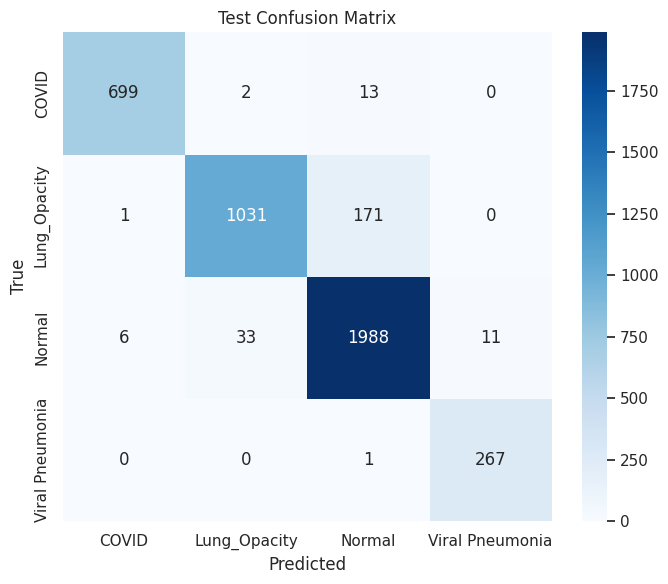

In [13]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix.png", dpi=300)
plt.show()


## 14. ROC Curves and AUC

ROC curves are calculated one-vs-rest for each class. Macro AUC is the average one-vs-rest AUC across classes.


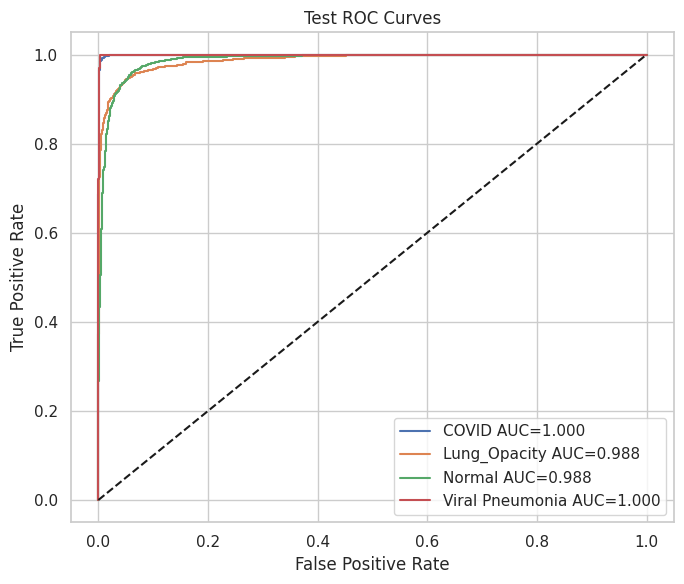

,class,auc
0,COVID,0.999596
1,Lung_Opacity,0.987809
2,Normal,0.987818
3,Viral Pneumonia,0.999820
4,macro,0.993761


In [14]:
y_true_bin = label_binarize(y_true, classes=list(range(len(CLASS_NAMES))))
auc_rows = []

plt.figure(figsize=(7, 6))
for i, class_name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    class_auc = auc(fpr, tpr)
    auc_rows.append({"class": class_name, "auc": class_auc})
    plt.plot(fpr, tpr, label=f"{class_name} AUC={class_auc:.3f}")

macro_auc = roc_auc_score(y_true_bin, y_prob, average="macro", multi_class="ovr")
auc_rows.append({"class": "macro", "auc": macro_auc})

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Test ROC Curves")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "roc_curves.png", dpi=300)
plt.show()

auc_df = pd.DataFrame(auc_rows)
display(auc_df)
auc_df.to_csv("test_auc_results.csv", index=False)


## 15. Grad-CAM Explainability

Grad-CAM highlights image regions that contribute strongly to the final class prediction. This simple implementation is used only when the selected final model is MobileNetV2. If the CNN baseline is selected, the notebook skips this section because the project goal is transfer-learning explainability.


,row_index,group,class_name
0,7,correct,COVID
1,11,correct,Lung_Opacity
2,0,correct,Normal
3,6,correct,Viral Pneumonia
4,5,misclassified_1,true_Normal_pred_Viral Pneumonia
5,17,misclassified_2,true_Lung_Opacity_pred_Normal


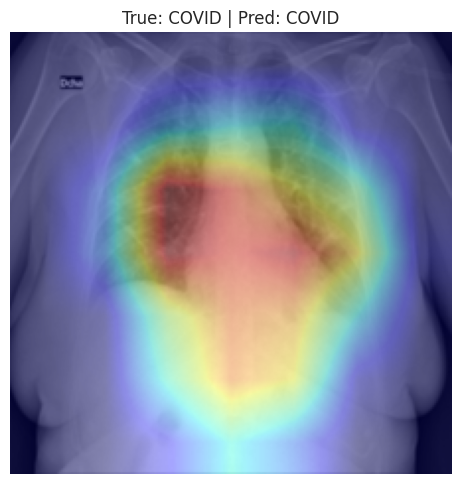

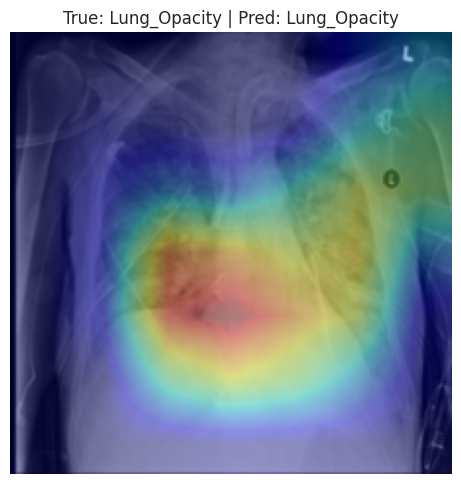

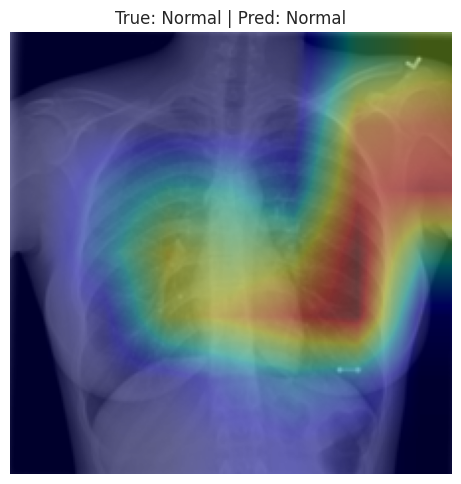

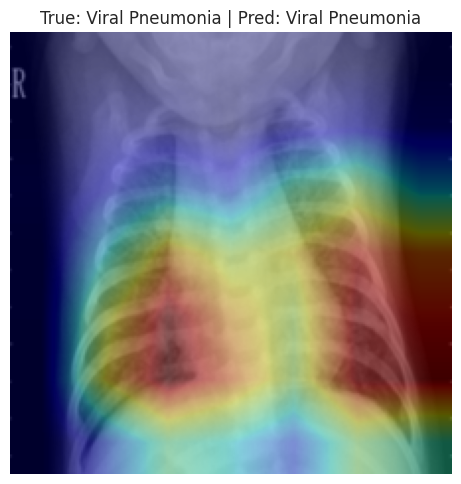

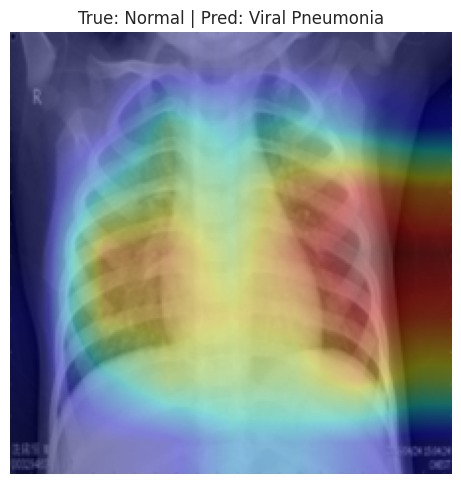

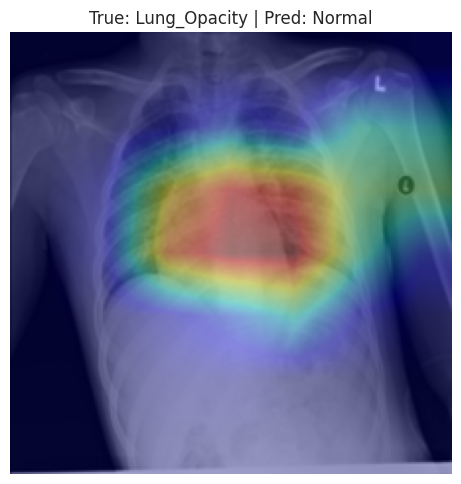

Grad-CAM figures saved to: figures/gradcam


In [15]:
GRADCAM_DIR = FIGURES_DIR / "gradcam"
GRADCAM_DIR.mkdir(exist_ok=True)

def denormalize_image(tensor):
    image = tensor.cpu().clone()
    for channel, mean, std in zip(image, imagenet_mean, imagenet_std):
        channel.mul_(std).add_(mean)
    image = image.clamp(0, 1).permute(1, 2, 0).numpy()
    return image

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.forward_hook = target_layer.register_forward_hook(self.save_activations)
        self.backward_hook = target_layer.register_full_backward_hook(self.save_gradients)

    def save_activations(self, module, inputs, output):
        self.activations = output.detach()

    def save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, image_tensor, class_index):
        self.model.zero_grad()
        output = self.model(image_tensor)
        score = output[:, class_index].sum()
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=(IMAGE_SIZE, IMAGE_SIZE), mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

    def close(self):
        self.forward_hook.remove()
        self.backward_hook.remove()

def save_gradcam_for_row(row_index, output_name):
    row = test_df.iloc[row_index]
    image = Image.open(row.filepath).convert("RGB")
    image_tensor = test_transform(image).unsqueeze(0).to(DEVICE)

    predicted_class = int(y_pred[row_index])
    heatmap = gradcam.generate(image_tensor, predicted_class)
    original = denormalize_image(image_tensor.squeeze(0))

    plt.figure(figsize=(5, 5))
    plt.imshow(original)
    plt.imshow(heatmap, cmap="jet", alpha=0.35)
    plt.axis("off")
    plt.title(f"True: {ID_TO_CLASS[int(y_true[row_index])]} | Pred: {ID_TO_CLASS[predicted_class]}")
    plt.tight_layout()
    plt.savefig(GRADCAM_DIR / output_name, dpi=300)
    plt.show()

if best_model_name == "MobileNetV2":
    final_model.eval()
    target_layer = final_model.features[-1]
    gradcam = GradCAM(final_model, target_layer)

    gradcam_rows = []

    # Best report style: one correctly classified example per class.
    for class_id, class_name in ID_TO_CLASS.items():
        correct_for_class = np.where((y_true == class_id) & (y_pred == class_id))[0]
        if len(correct_for_class) > 0:
            gradcam_rows.append({
                "row_index": int(correct_for_class[0]),
                "group": "correct",
                "class_name": class_name,
            })
        else:
            print(f"No correctly classified example found for {class_name}.")

    # Add a few mistakes, because errors are often the most informative cases.
    misclassified_indices = np.where(y_true != y_pred)[0][:2]
    for error_number, row_index in enumerate(misclassified_indices, start=1):
        true_name = ID_TO_CLASS[int(y_true[row_index])]
        pred_name = ID_TO_CLASS[int(y_pred[row_index])]
        gradcam_rows.append({
            "row_index": int(row_index),
            "group": f"misclassified_{error_number}",
            "class_name": f"true_{true_name}_pred_{pred_name}",
        })

    gradcam_selection_df = pd.DataFrame(gradcam_rows).drop_duplicates("row_index")
    display(gradcam_selection_df)
    gradcam_selection_df.to_csv(GRADCAM_DIR / "gradcam_selected_examples.csv", index=False)

    for _, row in gradcam_selection_df.iterrows():
        safe_class_name = row["class_name"].replace(" ", "_").replace("/", "_")
        output_name = f"{row['group']}_{safe_class_name}.png"
        save_gradcam_for_row(int(row["row_index"]), output_name)

    gradcam.close()
    print("Grad-CAM figures saved to:", GRADCAM_DIR)
else:
    print("Grad-CAM skipped because the selected model is CNN, not MobileNetV2.")
